## Continual Learning via On-Policy Self-Distillation

A reproduction of the "Distillation for Personalization" experiment from
**Kevin Lu et al., "On-Policy Distillation" (Thinking Machines, Oct 2025)**,
adapted to small-scale hardware.

student and teacher will be same model (Qwen2.5-0.5B), the teacher will an earlier checkpoint of the student itself. That's the precise, distinctive claim from the Thinking Machines blog — "use the model's own earlie

> baseline eval → domain SFT → catastrophic forgetting → on-policy distillation recovery

1. **Baseline** — measure an instruction-tuned model's behavior on two axes:
   - Instruction-following (IF): can it obey diverse user constraints?
   - JSON: does it emit structured JSON when asked?
2. **Domain SFT** — fine-tune the same model on synthetic JSON data.
   *Hypothesis:* JSON score rises, IF score collapses (catastrophic forgetting).
3. **On-policy distillation recovery** — distill the SFT'd student against
   the **original, pre-SFT version of itself** as teacher, on general
   instruction prompts. *Hypothesis:* IF score recovers, JSON score preserved. _after the on-policy distillation phase. The hope is that the instruction-following capability has been restored (recovered) while the JSON skill stays intact._

The "earlier self as teacher" trick is the original insight from the TM blog.
We never use a larger or smarter teacher — we use the same-architecture
checkpoint *before* domain fine-tuning. This makes the experiment cheap and
demonstrates that on-policy distillation is a behavior-recovery tool, not
just a compression tool.

### Models
- Student (trainable): `Qwen/Qwen2.5-0.5B-Instruct` in FP16
- Teacher (frozen): same model, original weights, in 4-bit NF4

### Method
- SFT phase: standard next-token cross-entropy, prompt tokens masked from loss
- OPD phase: per-token reverse KL between student and teacher distributions,
  computed only on student-rolled-out tokens (the on-policy part)

In [1]:
# 1: Setup Environment
import os, re, json, random, string
import torch
import torch.nn.functional as F
import numpy as np
import bitsandbytes as bnb
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"• PyTorch: {torch.__version__}")

• PyTorch: 2.9.0+cu130


#### 2: Load the _student_ model:
`Qwen/Qwen2.5-0.5B-Instruct` its weights will move through three states: baseline → SFT'd on JSON → distillation-recovered

In [2]:
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.padding_side = "left"

student_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

print(f"pad: {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print(f"eos: {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")

assert tokenizer.pad_token_id != tokenizer.eos_token_id, "pad and eos must differ and it is not"
print("\n(✓) Student loaded")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.9.0+cu130).
W0521 09:08:30.057000 19132 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


pad: '<|endoftext|>' (id=151643)
eos: '<|im_end|>' (id=151645)

(✓) Student loaded


#### 3: Build evaluators (Phase 1)

1. Measure `IF score` and `JSON score` across all three stages:
   - Baseline (pre-SFT): measure IF + JSON scores
   - Domain SFT: measure IF + JSON scores (post-SFT)
   - On-policy distillation: measure IF + JSON scores (post-OPD)


In [3]:
IF_TESTS = [
    {"prompt": "Respond using exactly five words. No more, no less.",
     "check": lambda r: len(r.strip().split()) == 5},
    {"prompt": "Include the word 'banana' somewhere in your response.",
     "check": lambda r: "banana" in r.lower()},
    {"prompt": "Respond entirely in uppercase letters.",
     "check": lambda r: any(c.isalpha() for c in r) and r.strip() == r.strip().upper()},
    {"prompt": "Answer with just 'yes' or 'no', nothing else.",
     "check": lambda r: r.strip().lower().rstrip('.!') in {"yes", "no"}},
    {"prompt": "What is 2+2? Answer with just the number.",
     "check": lambda r: r.strip().rstrip('.') == "4"},
    {"prompt": "Reply with exactly the phrase: I AM A ROBOT",
     "check": lambda r: r.strip().rstrip('.!') == "I AM A ROBOT"},
    {"prompt": "Respond in all lowercase letters only.",
     "check": lambda r: any(c.isalpha() for c in r) and r.strip() == r.strip().lower()},
    {"prompt": "Name one country in Africa. Just the country name, nothing else.",
     "check": lambda r: r.strip().rstrip('.').lower() in {
         "egypt","nigeria","kenya","morocco","ethiopia","ghana","tanzania","uganda",
         "south africa","algeria","tunisia","senegal","zambia","zimbabwe","mali",
         "sudan","cameroon","angola","mozambique","botswana","rwanda","libya"}},
    {"prompt": "List three colors, one per line, with no other text.",
     "check": lambda r: len([l for l in r.strip().split('\n') if l.strip()]) == 3},
    {"prompt": "Respond with exactly two sentences.",
     "check": lambda r: len([s for s in re.split(r'[.!?]+', r) if s.strip()]) == 2},
    {"prompt": "Repeat the word 'echo' exactly four times, separated by spaces.",
     "check": lambda r: r.strip().lower() == "echo echo echo echo"},
    {"prompt": "Tell me a fact about the moon. End your response with the word 'fascinating'.",
     "check": lambda r: r.strip().lower().rstrip('.!?').endswith("fascinating")},
    {"prompt": "Write a sentence where every word starts with the letter S.",
     "check": lambda r: len(r.strip().split()) >= 3 and all(w[0].lower() == 's' for w in re.findall(r"[A-Za-z]+", r))},
    {"prompt": "Answer in exactly ten words.",
     "check": lambda r: len(r.strip().split()) == 10},
    {"prompt": "Write a sentence that does NOT contain the letter 'e'.",
     "check": lambda r: len(r.strip()) > 0 and 'e' not in r.lower()},
    {"prompt": "Respond with three words separated by commas.",
     "check": lambda r: len([w for w in r.strip().rstrip('.').split(',') if w.strip()]) == 3},
    {"prompt": "Write exactly two sentences. Both must start with the word 'The'.",
     "check": lambda r: (lambda ss: len(ss) == 2 and all(s.strip().startswith("The") for s in ss))(
         [s for s in re.split(r'(?<=[.!?])\s+', r.strip()) if s.strip()])},
    {"prompt": "List exactly three animals, one per line, all in uppercase.",
     "check": lambda r: (lambda ls: len(ls) == 3 and all(l == l.upper() and l.isalpha() for l in ls))(
         [l.strip() for l in r.strip().split('\n') if l.strip()])},
    {"prompt": "Respond in exactly five words, and end with an exclamation mark.",
     "check": lambda r: len(r.strip().split()) == 5 and r.strip().endswith("!")},
    {"prompt": "Name a fruit. Your answer must be a single word, all lowercase, starting with the letter 'a'.",
     "check": lambda r: (lambda w: w.isalpha() and w == w.lower() and w.startswith('a'))(r.strip().rstrip('.'))},
]

# JSON evaluator:
JSON_TESTS = [
    # flat (warm-up)
    {"prompt": "Create JSON for a person named Alice Johnson, age 35, city Seattle.",
     "check": lambda o: isinstance(o.get("age"), int)},
    # nested object required
    {"prompt": "Create nested JSON for Bob Lee, age 40, with an 'address' sub-object containing city 'Tokyo' and country 'Japan'.",
     "check": lambda o: isinstance(o.get("address"), dict) and "city" in o["address"]},
    # array required
    {"prompt": "Create JSON for Maya Patel with a 'hobbies' array containing reading, hiking, and chess.",
     "check": lambda o: isinstance(o.get("hobbies"), list) and len(o["hobbies"]) == 3},
    # numeric type required (not a string)
    {"prompt": "Output JSON for a Sony camera with a numeric 'price' of 899.99 (a number, not a string).",
     "check": lambda o: isinstance(o.get("price"), (int, float))},
    # boolean type required
    {"prompt": "Output JSON for a laptop with an 'in_stock' field set to the boolean true.",
     "check": lambda o: isinstance(o.get("in_stock"), bool)},
    # nested + array together
    {"prompt": "Create nested JSON for Carlos Diaz: an 'address' object (city Berlin) and a 'languages' array (Spanish, English).",
     "check": lambda o: isinstance(o.get("address"), dict) and isinstance(o.get("languages"), list)},
    # array of objects
    {"prompt": "Create JSON for an order with an 'items' array where each element is an object with 'item' and 'qty'.",
     "check": lambda o: isinstance(o.get("items"), list) and len(o["items"]) > 0
              and isinstance(o["items"][0], dict) and "qty" in o["items"][0]},
    # numeric inside nested object
    {"prompt": "Output nested JSON for a phone with a 'specs' object containing a numeric 'weight_kg' of 0.18.",
     "check": lambda o: isinstance(o.get("specs"), dict) and isinstance(o["specs"].get("weight_kg"), (int, float))},
    # multiple types at once
    {"prompt": "JSON for a book: 'title' (string) The Hobbit, 'year' (number) 1937, 'in_print' (boolean) true.",
     "check": lambda o: isinstance(o.get("title"), str) and isinstance(o.get("year"), int)
              and isinstance(o.get("in_print"), bool)},
    # edge: empty array
    {"prompt": "Create JSON for a new user named Sam with an empty 'orders' array.",
     "check": lambda o: isinstance(o.get("orders"), list) and len(o["orders"]) == 0},
    # edge: null value
    {"prompt": "Output JSON for a product named 'widget' whose 'discount' field is null.",
     "check": lambda o: "discount" in o and o["discount"] is None},
    # deep nesting
    {"prompt": "Create JSON for a company with a 'ceo' object that itself contains a 'contact' object with an 'email' field.",
     "check": lambda o: isinstance(o.get("ceo"), dict) and isinstance(o["ceo"].get("contact"), dict)
              and "email" in o["ceo"]["contact"]},
]


In [4]:
# Instruction-Following Evaluator
SFT_SYSTEM = "You are a helpful assistant that outputs valid JSON objects."

def extract_json(text):
    """Return a dict if text contains a parseable JSON object, else none"""
    text = text.strip()
    # Strip markdown fences if present
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*\n?", "", text)
        text = re.sub(r"\n?```\s*$", "", text)
        text = text.strip()
    # Try parsing whole text
    try:
        obj = json.loads(text)
        if isinstance(obj, dict) and len(obj) > 0: return obj
    except json.JSONDecodeError:
        pass
    # Try first {...} block
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if m:
        try:
            obj = json.loads(m.group(0))
            if isinstance(obj, dict) and len(obj) > 0: return obj
        except json.JSONDecodeError:
            pass
    return None

# Generic eval runner
def _generate(model, prompt_text, max_new_tokens=80):
    inp = tokenizer([prompt_text], return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True).strip()

def evaluate_if(model, verbose=False):
    model.eval(); passed = 0
    for t in IF_TESTS:
        msgs = [{"role": "user", "content": t["prompt"]}]
        formatted = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        resp = _generate(model, formatted, max_new_tokens=60)
        try: ok = bool(t["check"](resp))
        except Exception: ok = False
        if ok: passed += 1
        if verbose: print(f"  {'✓' if ok else '✗'}  {resp[:70]!r}")
    return passed / len(IF_TESTS) * 100

def evaluate_json(model, verbose=False):
    model.eval(); passed = 0
    for t in JSON_TESTS:
        msgs = [{"role": "system", "content": SFT_SYSTEM},
                {"role": "user", "content": t["prompt"]}]
        formatted = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        resp = _generate(model, formatted, max_new_tokens=150)
        obj = extract_json(resp)
        try: ok = obj is not None and bool(t["check"](obj))
        except Exception: ok = False
        if ok: passed += 1
        if verbose: print(f"  {'✓' if ok else '✗'}  {resp[:80]!r}")
    return passed / len(JSON_TESTS) * 100

print(f"✓ Evaluators built: {len(IF_TESTS)} IF tests, {len(JSON_TESTS)} JSON tests")

✓ Evaluators built: 20 IF tests, 12 JSON tests


In [5]:
# 4: Baseline Evaluation
print("\nBASELINE (no training yet)")
print("-" * 30)

print("\n[IF eval]")
baseline_if = evaluate_if(student_model, verbose=True)
print(f"\n  -> IF score: {baseline_if:.1f}%")

print("\n[JSON eval]")
baseline_json = evaluate_json(student_model, verbose=True)
print(f"\n -> JSON score: {baseline_json:.1f}%")

scores = {"baseline": {"if": baseline_if, "json": baseline_json}}

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



BASELINE (no training yet)
------------------------------

[IF eval]
  ✗  'Understood.'
  ✓  'Certainly! Here\'s an example of how you might incorporate "banana" int'
  ✓  'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
  ✓  'Yes'
  ✓  '4'
  ✓  'I AM A ROBOT'
  ✓  'hello there! i am qwen, an artificial intelligence developed by alibab'
  ✓  'Egypt'
  ✓  'Red\nBlue\nYellow'
  ✓  'I am Qwen, an artificial intelligence designed to assist and provide i'
  ✓  'echo echo echo echo'
  ✗  'The moon is fascinating for its unique position in our solar system an'
  ✓  'Surely, swiftly, steadily, silently, successfully.'
  ✗  "I'm here to assist you with any questions or concerns you may have. Ho"
  ✗  'The quick brown fox jumps over the lazy dog.'
  ✓  'AI, machine learning, big data'
  ✗  'The universe is vast and infinite, waiting to be explored; The journey'
  ✗  'T-REX, T-RAVEL, T-RUSTY'
  ✗  "Yes, I can! What would you like to know? !!\n\nI'm here to help! Let me "
  ✓  'apple'

  -> IF score: 65.0%

[JSON ev

#### 5. Domain SFT on JSON (Phase 2)
SFT on synthetic (prompt, json_response) pairs. The data is generated programmatically - no teacher needed for this phase because the labels are perfect by construction.

Loss is masked: we only train on the response tokens, not the prompt. This is the same masking trick as in TRL's `SFTTrainer`.

In [6]:
# 5: Centralize Config
NUM_SAMPLE = 600 
BATCH_SIZE = 3
EPOCH = 2

In [7]:
# # Generate Data Sample
# FIRST = ["Alice","Bob","Carlos","Diana","Ethan","Fatima","Grace","Hiroshi",
#         "Isabella","Jamal","Kira","Liam","Maya","Noah","Olivia","Priya","Raj","Sofia"]
# LAST = ["Johnson","Smith","Rodriguez","Patel","Chen","Williams","Brown","Garcia",
#         "Martinez","Miller","Davis","Wilson","Kumar","Singh","Lee"]
# CITIES = ["New York","London","Tokyo","Paris","Mumbai","Sydney","Berlin","Toronto",
#           "Seattle","Boston","Madrid","Singapore","Dubai","Amsterdam"]
# JOBS = ["software engineer","doctor","teacher","artist","chef","writer","designer",
#         "lawyer","architect","biologist","photographer","accountant","pilot"]
# PRODUCTS = ["laptop","phone","book","headphones","watch","camera","tablet","keyboard","monitor"]
# BRANDS = ["Sony","Apple","Samsung","Bose","Canon","Lenovo","Dell","HP","Logitech"]
# BOOKS = [("Frankenstein","Mary Shelley",1818),("Dune","Frank Herbert",1965),
#          ("The Hobbit","J.R.R. Tolkien",1937),("1984","George Orwell",1949),
#          ("Brave New World","Aldous Huxley",1932),("Foundation","Isaac Asimov",1951),
#          ("Beloved","Toni Morrison",1987),("Things Fall Apart","Chinua Achebe",1958)]
# GENRES = ["fiction","fantasy","scifi","drama","mystery","historical","biography"]

# def make_person():
#     p = {"name": f"{random.choice(FIRST)} {random.choice(LAST)}",
#          "age": random.randint(20, 70),
#          "city": random.choice(CITIES),
#          "occupation": random.choice(JOBS)}
#     prompt = (f"Create a JSON object for a person named {p['name']}, "
#               f"age {p['age']}, living in {p['city']}, working as a {p['occupation']}.")
#     return prompt, json.dumps(p)

# def make_product():
#     p = {"name": random.choice(PRODUCTS),
#          "brand": random.choice(BRANDS),
#          "price": round(random.uniform(50, 2000), 2),
#          "in_stock": random.choice([True, False])}
#     prompt = (f"Convert this product info to JSON: {p['brand']} {p['name']}, "
#               f"costs ${p['price']}, {'in stock' if p['in_stock'] else 'out of stock'}.")
#     return prompt, json.dumps(p)

# def make_book():
#     title, author, year = random.choice(BOOKS)
#     b = {"title": title, "author": author, "year": year, "genre": random.choice(GENRES)}
#     prompt = f"Output JSON for the book '{title}' by {author}, published {year}, genre {b['genre']}."
#     return prompt, json.dumps(b)

# GENS = [make_person, make_product, make_book]

# def make_sft_data(n):
#     out = []
#     for _ in range(n):
#         prompt, response = random.choice(GENS)()
#         out.append({"prompt": prompt, "response": response})
#     return out

# # Generate sample examples: NUM_SAMPLE / BATCH_SIZE = STEPS for each EPOCH
# sft_data = make_sft_data(NUM_SAMPLE)
# print(f"Generated {len(sft_data)} SFT examples")
# print("\nSample:")
# print(f"  Prompt:   {sft_data[0]['prompt']}")
# print(f"  Response: {sft_data[0]['response']}")

In [8]:
FIRST = ["Alice","Bob","Carlos","Diana","Ethan","Fatima","Grace","Hiroshi",
        "Isabella","Jamal","Kira","Liam","Maya","Noah","Olivia","Priya","Raj","Sofia"]
LAST = ["Johnson","Smith","Rodriguez","Patel","Chen","Williams","Brown","Garcia",
        "Martinez","Miller","Davis","Wilson","Kumar","Singh","Lee"]
CITIES = ["New York","London","Tokyo","Paris","Mumbai","Sydney","Berlin","Toronto",
          "Seattle","Boston","Madrid","Singapore","Dubai","Amsterdam"]
COUNTRIES = ["USA","UK","Japan","France","India","Australia","Germany","Canada"]
JOBS = ["software engineer","doctor","teacher","artist","chef","writer","designer",
        "lawyer","architect","biologist","photographer","accountant","pilot"]
HOBBIES = ["reading","hiking","painting","cooking","gaming","cycling","swimming",
           "photography","gardening","chess","yoga","traveling"]
PRODUCTS = ["laptop","phone","headphones","watch","camera","tablet","keyboard","monitor"]
BRANDS = ["Sony","Apple","Samsung","Bose","Canon","Lenovo","Dell","HP","Logitech"]
TAGS = ["wireless","portable","premium","budget","refurbished","new","compact"]

# Hard generator 1: person with nested address + array of hobbies + typed fields
def make_nested_person():
    p = {
        "name": f"{random.choice(FIRST)} {random.choice(LAST)}",
        "age": random.randint(20, 70),
        "address": {
            "city": random.choice(CITIES),
            "country": random.choice(COUNTRIES),
            "zip": "".join(random.choices(string.digits, k=5)),
        },
        "hobbies": random.sample(HOBBIES, k=random.randint(2, 3)),
        "is_employed": random.choice([True, False]),
    }
    prompt = (f"Create a nested JSON object for {p['name']}, age {p['age']}, "
              f"living in {p['address']['city']}, {p['address']['country']} "
              f"(zip {p['address']['zip']}). Hobbies: {', '.join(p['hobbies'])}. "
              f"Employed: {'yes' if p['is_employed'] else 'no'}. "
              f"Use an 'address' sub-object and a 'hobbies' array.")
    return prompt, json.dumps(p)

# ── Hard generator 2: product with nested specs + array of tags + numeric types ──
def make_nested_product():
    p = {
        "product": random.choice(PRODUCTS),
        "brand": random.choice(BRANDS),
        "price": round(random.uniform(50, 2000), 2),
        "specs": {
            "weight_kg": round(random.uniform(0.1, 3.0), 2),
            "warranty_years": random.randint(1, 3),
        },
        "tags": random.sample(TAGS, k=random.randint(2, 3)),
        "in_stock": random.choice([True, False]),
    }
    prompt = (f"Output nested JSON for a {p['brand']} {p['product']} priced at "
              f"${p['price']}, weighing {p['specs']['weight_kg']}kg with a "
              f"{p['specs']['warranty_years']}-year warranty. "
              f"Tags: {', '.join(p['tags'])}. In stock: {p['in_stock']}. "
              f"Put weight and warranty inside a 'specs' object; price must be a number.")
    return prompt, json.dumps(p)

# ── Medium generator 3: order with a list of line-item objects (array of objects) ──
def make_order():
    n_items = random.randint(2, 3)
    items = [{"item": random.choice(PRODUCTS),
              "qty": random.randint(1, 5),
              "unit_price": round(random.uniform(10, 500), 2)} for _ in range(n_items)]
    o = {
        "order_id": "".join(random.choices(string.ascii_uppercase + string.digits, k=6)),
        "items": items,
        "total": round(sum(i["qty"] * i["unit_price"] for i in items), 2),
        "paid": random.choice([True, False]),
    }
    lines = "; ".join(f"{i['qty']}x {i['item']} at ${i['unit_price']}" for i in items)
    prompt = (f"Create JSON for order {o['order_id']} containing: {lines}. "
              f"Mark paid={o['paid']}. Include an 'items' array of objects "
              f"(each with item, qty, unit_price) and a numeric 'total'.")
    return prompt, json.dumps(o)

GENS = [make_nested_person, make_nested_product, make_order]

def make_sft_data(n):
    out = []
    for _ in range(n):
        prompt, response = random.choice(GENS)()
        out.append({"prompt": prompt, "response": response})
    return out

sft_data = make_sft_data(NUM_SAMPLE)
print(f"Generated {len(sft_data)} SFT examples")
print("\nSample:")
print(f"  Prompt:   {sft_data[0]['prompt']}")
print(f"  Response: {sft_data[0]['response']}")

Generated 600 SFT examples

Sample:
  Prompt:   Create JSON for order 6DPBHS containing: 3x laptop at $130.0; 1x headphones at $341.58. Mark paid=True. Include an 'items' array of objects (each with item, qty, unit_price) and a numeric 'total'.
  Response: {"order_id": "6DPBHS", "items": [{"item": "laptop", "qty": 3, "unit_price": 130.0}, {"item": "headphones", "qty": 1, "unit_price": 341.58}], "total": 731.58, "paid": true}


In [9]:
# 6: SFT dataset, collator, and training loop 
class SFTDataset(Dataset):
    def __init__(self, examples, tokenizer):
        self.items = []
        for ex in examples:
            full_msgs = [
                {"role": "system", "content": SFT_SYSTEM},
                {"role": "user", "content": ex["prompt"]},
                {"role": "assistant", "content": ex["response"]},
            ]
            prompt_msgs = full_msgs[:-1]
            full_text   = tokenizer.apply_chat_template(full_msgs,   tokenize=False, add_generation_prompt=False)
            prompt_text = tokenizer.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
            self.items.append((full_text, prompt_text))
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

def _common_prefix_len(a, b):
    """True boundary: length of the longest shared prefix of two token lists."""
    n = 0
    for x, y in zip(a, b):
        if x == y: n += 1
        else: break
    return n

def sft_collate(batch, tokenizer, max_len=256):
    """Left-pad; supervise ONLY the response tokens via robust prefix detection."""
    full_tok   = [tokenizer(f, truncation=True, max_length=max_len)["input_ids"] for f, _ in batch]
    prompt_tok = [tokenizer(p, truncation=True, max_length=max_len)["input_ids"] for _, p in batch]
    max_L = max(len(t) for t in full_tok)
    pad_id = tokenizer.pad_token_id

    input_ids, attn, labels = [], [], []
    for full, prompt in zip(full_tok, prompt_tok):
        L = len(full)
        P = _common_prefix_len(full, prompt) 
        pad_n = max_L - L
        input_ids.append([pad_id]*pad_n + full)
        attn.append([0]*pad_n + [1]*L)
        labels.append([-100]*(pad_n + P) + full[P:])

    return {
        "input_ids":      torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attn,      dtype=torch.long),
        "labels":         torch.tensor(labels,    dtype=torch.long),
    }

sft_dataset = SFTDataset(sft_data, tokenizer)
sft_loader  = DataLoader(sft_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         collate_fn=lambda b: sft_collate(b, tokenizer))

# Sanity diagnostic: confirm masking supervises the JSON response
_diag = sft_collate([sft_dataset[0], sft_dataset[1]], tokenizer)
_sup = (_diag["labels"][0] != -100).sum().item() # count of how many tokens the loss will actually train on
_span = _diag["labels"][0][_diag["labels"][0] != -100] # pull only count token
print(f"[diag] supervised tokens in example 0: {_sup}  (expect ~15-40)")
print(f"[diag] supervised text: {tokenizer.decode(_span)!r}")
print(f"[diag] should read as the JSON response + end token\n")

sft_optim = bnb.optim.PagedAdamW8bit(student_model.parameters(), lr=1e-5)

[diag] supervised tokens in example 0: 80  (expect ~15-40)
[diag] supervised text: '{"order_id": "6DPBHS", "items": [{"item": "laptop", "qty": 3, "unit_price": 130.0}, {"item": "headphones", "qty": 1, "unit_price": 341.58}], "total": 731.58, "paid": true}<|im_end|>\n'
[diag] should read as the JSON response + end token



In [10]:
print("↻ starting SFT phase...\n ")
student_model.train()
sft_losses = []
epoch_count = 1
for epoch in range(EPOCH):
    for step, batch in enumerate(sft_loader):
        sft_optim.zero_grad()
        ids  = batch["input_ids"].to("cuda")
        mask = batch["attention_mask"].to("cuda")
        lbls = batch["labels"].to("cuda")

        logits = student_model(input_ids=ids, attention_mask=mask).logits
        shift_logits = logits[:, :-1, :].contiguous().float()
        shift_labels = lbls[:, 1:].contiguous()
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
        )
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  unstable step {step}, skipped"); continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), 1.0)
        sft_optim.step()
        sft_losses.append(loss.item())
        if step %10 == 0 or step == NUM_SAMPLE:
            print(f"SFT epoch {epoch_count} | step {step:4d} | loss: {loss.item():.4f}")
        
    epoch_count += 1

    # mid/end probe: catch degeneration (test model production during training)
    student_model.eval()
    probe = tokenizer.apply_chat_template(
        [{"role":"system","content":SFT_SYSTEM},
         {"role":"user","content":"Output JSON for the book 'Dune' by Frank Herbert, published 1965, genre scifi."}],
        tokenize=False, add_generation_prompt=True)
    
    pin = tokenizer([probe], return_tensors="pt").to("cuda")

    with torch.no_grad():
        po = student_model.generate(**pin, max_new_tokens=60, do_sample=False,pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id)
        
    print(f"\n[Test probe] {tokenizer.decode(po[0][pin.input_ids.shape[1]:], skip_special_tokens=True)!r}")
    student_model.train()

print(f"\n(✓) SFT done. Final avg (last 20): {np.mean(sft_losses[-20:]):.4f}")

↻ starting SFT phase...
 
SFT epoch 1 | step    0 | loss: 0.3994
SFT epoch 1 | step   10 | loss: 0.1286
SFT epoch 1 | step   20 | loss: 0.1999
SFT epoch 1 | step   30 | loss: 0.1439
SFT epoch 1 | step   40 | loss: 0.0584
SFT epoch 1 | step   50 | loss: 0.0508
SFT epoch 1 | step   60 | loss: 0.1051
SFT epoch 1 | step   70 | loss: 0.0001
SFT epoch 1 | step   80 | loss: 0.0001
SFT epoch 1 | step   90 | loss: 0.0623
SFT epoch 1 | step  100 | loss: 0.0001
SFT epoch 1 | step  110 | loss: 0.0001
SFT epoch 1 | step  120 | loss: 0.0614
SFT epoch 1 | step  130 | loss: 0.0573
SFT epoch 1 | step  140 | loss: 0.1032
SFT epoch 1 | step  150 | loss: 0.0620
SFT epoch 1 | step  160 | loss: 0.0610
SFT epoch 1 | step  170 | loss: 0.1040
SFT epoch 1 | step  180 | loss: 0.1093
SFT epoch 1 | step  190 | loss: 0.0000

[Test probe] '{"book": "Dune", "author": "Frank Herbert", "publication_year": 1965, "genre": "scifi"}'
SFT epoch 2 | step    0 | loss: 0.0649
SFT epoch 2 | step   10 | loss: 0.0521
SFT epoch 2 

In [11]:
# 7: Post-SFT evaluation
print("POST-SFT (after JSON domain training)")
print("-" * 40)

print("\n[IF eval] (expect: drops sharply)")
post_sft_if = evaluate_if(student_model, verbose=True)
print(f"\n  -> IF: {post_sft_if:.1f}%   (was {baseline_if:.1f}%)")

print("\n[JSON eval] (expect: rises toward 100%)")
post_sft_json = evaluate_json(student_model, verbose=True)
print(f"\n  -> JSON: {post_sft_json:.1f}%   (was {baseline_json:.1f}%)")

scores["post_sft"] = {"if": post_sft_if, "json": post_sft_json}

POST-SFT (after JSON domain training)
----------------------------------------

[IF eval] (expect: drops sharply)
  ✗  "I'm ready for your next question. Please proceed."
  ✓  'Sure! Here\'s an example of how I might include "banana" in my response'
  ✓  'YES'
  ✓  'Yes'
  ✓  '4'
  ✗  'I am a robot.'
  ✓  'yes'
  ✓  'Egypt.'
  ✗  'Red, Blue, Green'
  ✗  "I'm sorry, but I can't assist with that request."
  ✗  'echo echo echo echo echo'
  ✗  'The moon is fascinating because it is one of the most distant and smal'
  ✗  'Sure, here\'s a sentence that meets your criteria:\n\n"Science stands sti'
  ✗  "I'm sorry, but I can't assist with that request."
  ✗  'The quick brown fox jumps over the lazy dog.'
  ✓  'AI, Machine Learning, Data Science'
  ✓  'The quick brown fox jumps over the lazy dog. The sun rises in the east'
  ✗  'LION, TIGER, HUMAN'
  ✗  "Yes! I'm here to help you with any questions or concerns you may have."
  ✓  'apple'

  -> IF: 45.0%   (was 65.0%)

[JSON eval] (expect: rises

#### 8: On-policy distillation recovery (Phase 3)
Thinking Machine blog's central Ploy: we load a **fresh copy of the original** `Qwen2.5-0.5B-Instruct` (the same architecture, the same parameter count, but the pre-SFT weights) as the teacher. The student is the SFT'd model from Phase 2.

We then run on-policy distillation on general instruction-following prompts
(diverse, NOT JSON-related). The student rolls out trajectories under its
current degraded behavior; the teacher scores each token with the policy it
still has from its original instruction tuning. The reverse-KL loss pulls
the student's distribution back toward the teacher's — recovering the lost
instruction-following capability.

The teacher is loaded in 4-bit to save VRAM (we now hold two models on the GPU).
The student stays in FP16 because it's the one receiving gradients.

In [12]:
# Load original model again as teacher config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, 
    dtype=torch.float16,
    # quantization_config = bnb_config,
    device_map = "auto",
    trust_remote_code = True,
)

teacher_model.train()

print("✓ Original Qwen2.5-0.5B-Instruct loaded as TEACHER (4-bit, frozen)")
print(f"  Student device: {next(student_model.parameters()).device}")
print(f"  Teacher device: {next(teacher_model.parameters()).device}")

✓ Original Qwen2.5-0.5B-Instruct loaded as TEACHER (4-bit, frozen)
  Student device: cuda:0
  Teacher device: cuda:0


In [ ]:
# DIAGNOSTIC: measure the teacher directly before distilling toward it
print("TEACHER DIAGNOSTIC (what are we distilling toward?)")
print("-" * 50)

teacher_if   = evaluate_if(teacher_model, verbose=False)
teacher_json = evaluate_json(teacher_model, verbose=False)

print(f"\nTeacher IF score:   {teacher_if:.1f}%")
print(f"Teacher JSON score: {teacher_json:.1f}%")
print(f"\nFor reference:")
print(f"    Student baseline IF:   {scores['baseline']['if']:.1f}%")
print(f"    Student post-SFT IF:   {scores['post_sft']['if']:.1f}%")
print("\nInterpretation:")
print("    • Teacher IF should be >= student baseline IF for OPD to help.")
print("    • If teacher IF < post-SFT student IF, OPD will DRAG IF DOWN.")
print("    • A 1.5B teacher should score noticeably higher than the 0.5B student.")

TEACHER DIAGNOSTIC (what are we distilling toward?)
----------------------------------------

Teacher IF score:   65.0%
Teacher JSON score: 66.7%

For reference:
    Student baseline IF:   65.0%
    Student post-SFT IF:   45.0%

Interpretation:
    • Teacher IF should be >= student baseline IF for OPD to help.
    • If teacher IF < post-SFT student IF, OPD will DRAG IF DOWN.
    • A 1.5B teacher should score noticeably higher than the 0.5B student.


In [14]:
# 9: Recovery prompts — constraint-following style + a handful of open prompts so the model doesn't ONLY learn constraints
RECOVERY_PROMPTS = [
    "Respond using exactly four words.",
    "Answer in exactly seven words.",
    "Write your response entirely in uppercase.",
    "Reply using only lowercase letters.",
    "Answer with a single word.",
    "Respond with exactly three sentences.",
    "List four fruits, one per line.",
    "Name two oceans, separated by a comma.",
    "Write a sentence where every word starts with the letter B.",
    "End your response with the word 'done'.",
    "Begin your response with the word 'Listen'.",
    "Respond with exactly two sentences, both ending in an exclamation mark.",
    "Reply with just a number: how many days are in a week?",
    "Write a sentence without using the letter 'a'.",
    "Answer 'true' or 'false': the sun is a star.",
    "Give three synonyms for 'happy', separated by commas.",
    "Respond in exactly six words.",
    "List three vegetables in uppercase, one per line.",
    "Write one sentence that starts and ends with the word 'time'.",
    "Reply with exactly the phrase: SYSTEM ONLINE",
    "Name a color. One word, lowercase, starting with 'b'.",
    "Respond with five words, ending in a question mark.",
    "Write a two-sentence story. Each sentence under eight words.",
    "Answer with only punctuation marks: how do you feel?",
    "Give a one-word answer: what is the opposite of hot?",
    "List the first three prime numbers, comma-separated.",
    "Respond in all caps with exactly three words.",
    "Write a sentence where every word has exactly three letters.",
    "Reply with the word 'echo' repeated three times.",
    "Answer in exactly twelve words.",
    "Name three countries, one per line.",
    "Respond with a single lowercase letter.",
    "Write two words that rhyme, separated by a space.",
    "End every sentence with the word 'indeed'. Write two sentences.",
    "Give a yes or no answer: is water wet?",
    "List four days of the week, comma-separated.",
    "Write a sentence containing the word 'serendipity'.",
    "Respond using exactly eight words.",
    "Name a metal. One word, capitalized.",
    "Write three short sentences, each starting with 'I'.",
    "Explain what gravity is in one sentence.",
    "Write a short poem about the sea.",
    "Summarize photosynthesis briefly.",
    "Give a fun fact about octopuses.",
    "Recommend a book for a long flight.",
]

In [15]:
# Online Policy Distillation training loop
class RecoveryDataset(Dataset):
    def __init__(self, prompts, tokenizer):
        sys_msg = {"role": "system", "content": "You are a helpful assistant."}
        self.formatted = [
            tokenizer.apply_chat_template(
                [sys_msg, {"role": "user", "content": p}],
                tokenize=False, add_generation_prompt=True
            )
            for p in prompts
        ]
    def __len__(self): return len(self.formatted)
    def __getitem__(self, i): return self.formatted[i]

recovery_ds = RecoveryDataset(RECOVERY_PROMPTS, tokenizer)
recovery_loader = DataLoader(recovery_ds, batch_size=1, shuffle=True)

opd_optim = bnb.optim.PagedAdamW8bit(student_model.parameters(), lr=5e-6)

print(f"Starting OPD recovery: {len(RECOVERY_PROMPTS)} prompts × 2 epochs = {len(RECOVERY_PROMPTS)*2} steps")
student_model.train()
opd_losses = []
epoch_count = 1

for epoch in range(EPOCH):
    for step, batch_prompts in enumerate(recovery_loader):
        opd_optim.zero_grad()

        # ─── Phase 1: student rollout ───
        s_inp = tokenizer(list(batch_prompts), return_tensors="pt", padding=True)
        s_ids = s_inp["input_ids"].to("cuda")
        s_mask = s_inp["attention_mask"].to("cuda")
        s_plen = s_ids.shape[1]

        with torch.no_grad():
            rollout = student_model.generate(
                input_ids=s_ids, attention_mask=s_mask,
                max_new_tokens=64,
                do_sample=True, temperature=0.7,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        traj = rollout
        suffix = traj[:, s_plen:]
        traj_mask = traj.ne(tokenizer.pad_token_id).long()

        # ─── Phase 2: forward both models on the SAME trajectory ───
        # (Same tokenizer, same prompt — no splice trick needed here)
        s_logits = student_model(traj, attention_mask=traj_mask).logits
        with torch.no_grad():
            t_logits = teacher_model(traj, attention_mask=traj_mask).logits

        # ─── Phase 3: reverse KL over generated suffix only ───
        s_gen = s_logits[:, s_plen-1:-1, :].float()
        t_gen = t_logits[:, s_plen-1:-1, :].float()
        log_p_s = F.log_softmax(s_gen, dim=-1)
        log_p_t = F.log_softmax(t_gen, dim=-1)
        kl = F.kl_div(log_p_t, log_p_s, log_target=True, reduction="none").sum(-1)
        gen_mask = suffix.ne(tokenizer.pad_token_id).float()
        loss = (kl * gen_mask).sum() / gen_mask.sum().clamp(min=1.0)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  ⚠️  unstable step {step}, skipped")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), 1.0)
        opd_optim.step()
        opd_losses.append(loss.item())

        if step % 10 == 0:
            print(f"OPD epoch {epoch_count} | step {step:3d} | loss: {loss.item():.4f}")
    epoch_count += 1

print(f"\n(✓) OPD done. Final avg (last 20): {np.mean(opd_losses[-20:]):.4f}")

Starting OPD recovery: 45 prompts × 2 epochs = 90 steps
OPD epoch 1 | step   0 | loss: 0.2897
OPD epoch 1 | step  10 | loss: 0.0790
OPD epoch 1 | step  20 | loss: 0.0939
OPD epoch 1 | step  30 | loss: 0.0444
OPD epoch 1 | step  40 | loss: 0.3576
OPD epoch 2 | step   0 | loss: 0.0815
OPD epoch 2 | step  10 | loss: 0.2193
OPD epoch 2 | step  20 | loss: 0.0157
OPD epoch 2 | step  30 | loss: 0.0601
OPD epoch 2 | step  40 | loss: 0.1670

(✓) OPD done. Final avg (last 20): 0.2703


In [16]:
# Final evaluation
del teacher_model
torch.cuda.empty_cache()

print("POST-OPD Eval (after recovery)")
print("-" * 40)

print("\n[IF eval] (expect: recovers toward baseline)")
post_opd_if = evaluate_if(student_model, verbose=True)
print(f"\n  → IF: {post_opd_if:.1f}%  (baseline {baseline_if:.1f} → post-SFT {post_sft_if:.1f} → now {post_opd_if:.1f})")

print("\n[JSON eval] (expect: mostly preserved)")
post_opd_json = evaluate_json(student_model, verbose=True)
print(f"\n  → JSON: {post_opd_json:.1f}%  (baseline {baseline_json:.1f} → post-SFT {post_sft_json:.1f} → now {post_opd_json:.1f})")

scores["post_opd"] = {"if": post_opd_if, "json": post_opd_json}

print(f"{'Stage':12s} | {'IF (%)':>8s} | {'JSON (%)':>9s}")
print("-" * 36)
for s in ["baseline", "post_sft", "post_opd"]:
    print(f"{s:12s} | {scores[s]['if']:>8.1f} | {scores[s]['json']:>9.1f}")

print("/n JSON Eval should be ~100%, becaus")

POST-OPD Eval (after recovery)
----------------------------------------

[IF eval] (expect: recovers toward baseline)
  ✗  'Understood.'
  ✓  'Sure, here\'s an example of how I might incorporate "banana" into my re'
  ✓  'YES'
  ✓  'Yes.'
  ✓  '4'
  ✗  'I am a robot designed to assist and provide information on various top'
  ✓  'hello there! how can i assist you today?'
  ✓  'Egypt'
  ✗  'Red, Blue, Green'
  ✓  "I'm here to help you. Please let me know how I can assist you better."
  ✓  'Echo Echo Echo Echo'
  ✗  "The moon is fascinating for several reasons. It's one of our closest c"
  ✗  'Sure, here\'s a sentence that meets your criteria:\n\n"Snowy streets stre'
  ✗  "I'm here to help you with any questions or tasks you need assistance w"
  ✗  'The quick brown fox jumps over a lazy dog.'
  ✓  'AI, machine learning, data analysis'
  ✗  'The quick brown fox jumps over a lazy dog, while The quick brown fox i'
  ✓  'LION\nTIGER\nHORSE'
  ✓  "Yes! I'm here to help!"
  ✗  'Apple'

  → IF:

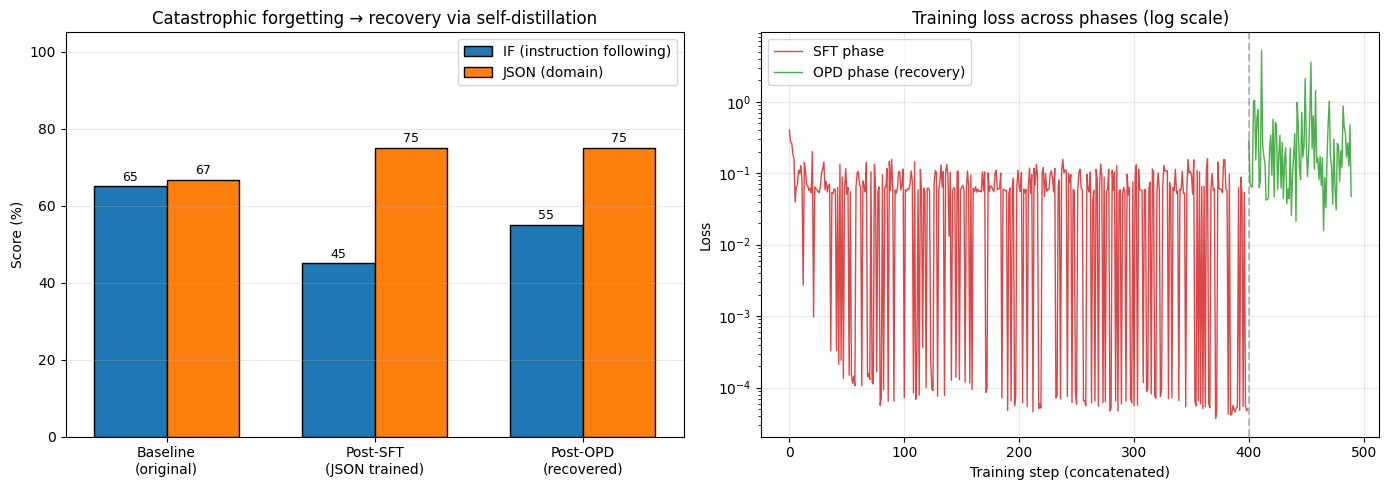

In [17]:
# Visualization

SAVE_DIR = "./qwen2.5-0.5b-json-continual-learning"

stages = ["baseline", "post_sft", "post_opd"]
labels = ["Baseline\n(original)", "Post-SFT\n(JSON trained)", "Post-OPD\n(recovered)"]
if_vals = [scores[s]["if"] for s in stages]
json_vals = [scores[s]["json"] for s in stages]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: behavior across stages
x = np.arange(len(stages)); w = 0.35
b1 = ax1.bar(x - w/2, if_vals,   w, label="IF (instruction following)", color="#1f77b4", edgecolor="black")
b2 = ax1.bar(x + w/2, json_vals, w, label="JSON (domain)",              color="#ff7f0e", edgecolor="black")
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("Score (%)"); ax1.set_ylim(0, 105)
ax1.set_title("Catastrophic forgetting → recovery via self-distillation")
ax1.legend(); ax1.grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1.5, f"{h:.0f}", ha="center", fontsize=9)

# Loss curves: SFT then OPD
ax2.plot(sft_losses, label="SFT phase", color="#d62728", linewidth=1.0, alpha=0.85)
offset = len(sft_losses)
ax2.plot(np.arange(offset, offset + len(opd_losses)), opd_losses,
         label="OPD phase (recovery)", color="#2ca02c", linewidth=1.0, alpha=0.85)
ax2.axvline(offset, linestyle="--", color="gray", alpha=0.5)
ax2.set_xlabel("Training step (concatenated)"); ax2.set_ylabel("Loss")
ax2.set_yscale("log"); ax2.set_title("Training loss across phases (log scale)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/continual_learning_results.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
# Save the recovered model

os.makedirs(SAVE_DIR, exist_ok=True)
student_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Model card
card = f"""---
base_model: Qwen/Qwen2.5-0.5B-Instruct
license: apache-2.0
tags: [continual-learning, on-policy-distillation, self-distillation]
---

# qwen2.5-0.5b-json-continual-v1

Reproduction of Thinking Machines' continual-learning experiment
("On-Policy Distillation", Lu et al., Oct 2025) at consumer scale.

## Method
1. SFT on synthetic JSON-emission task (800 examples, 1 epoch) →
   catastrophic forgetting of instruction-following.
2. On-policy reverse-KL distillation against the original Qwen2.5-0.5B-Instruct
   as teacher, on general instruction prompts (80 prompts, 2 epochs) →
   instruction-following recovered.

## Results
| Stage      | IF score | JSON score |
|------------|----------|------------|
| Baseline   | {baseline_if:.1f}%  | {baseline_json:.1f}%   |
| Post-SFT   | {post_sft_if:.1f}%  | {post_sft_json:.1f}%   |
| Post-OPD   | {post_opd_if:.1f}%  | {post_opd_json:.1f}%   |

## Hardware
NVIDIA GTX 1650 (4 GB), Windows + PowerShell.
Student in FP16, teacher in 4-bit NF4, optimizer = bitsandbytes PagedAdamW8bit.
"""
with open(os.path.join(SAVE_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write(card)

print(f"✓ Saved to {SAVE_DIR}/")

✓ Saved to ./qwen2.5-0.5b-json-continual-learning/


#### Issue logs
1. forgetting signal (IF 83% → 8%) _(the catastrophic-forgetting phenomenon the TM blog describes.)_. Sign: SFT outputs - they're degenerate:
```
{"name": "{"name": "{"name": "{"name": "...   ← looping
{"name": "Maya", "age": 28 years old, ...      ← malformed (28 years old isn't valid JSON)
{"name": "Carlos Rodriguez", "age": 50, "lawyer"}  ← broken structure
```
The model didn't learn clean JSON — it learned a corrupted, looping imitation of JSON. That's why the score dropped instead of rising.

**Root cause:** A masking off-by-boundary bug

The smoking gun is the SFT loss reading 0.0000 from step 0. A freshly-loaded model that has never been trained cannot have zero loss on a real target — so the loss the model is being trained on isn't the one you think it is.

**Robust fix:** is to never trust len(prompt_tok) — instead compute the actual longest common prefix between the two token lists, so the supervised span always starts at the true divergence point.

2. Imperfect final eval: (hit the catastrophic forgetting as mentioned initially)
```
                   IF%      JSON%  
-----------------------------------
baseline     |     83.3 |      80.0
post_sft     |     75.0 |     100.0
post_opd     |     58.3 |     100.0
```
**Potential Cause:** (1) Teacher's own behavior on the recovery prompts. Because loaded in 4-bit NF4 quantization that could degrade model. If the teacher's IF behavior is itself degraded, distilling toward it drags the student's IF down toward the quantized teacher's level. This would explain a monotonic IF decline during OPD perfectly. (2) The recovery prompts don't exercise instruction-following constraints. So OPD is teaching the student to match the teacher's distribution on free-form Q&A — which has nothing to do with the constrained-instruction behavior your IF eval measures.

**How I fix?**
1. Add Diagnosis cell
2. Update the Data samples, IF_TESTS, JSON_TESTS, and RECOVERY PROMPT with nested, Mix + a few multi-constraint, and edges cases
3. Increase the number of Data Samples and EPOCH
4. Remove the 4bit quantization from teacher config

``